Projekat iz predmeta Duboko učenje i neuronske mreže:


---


# Primena deep learninga za preporuku proizvoda u elektrosnkoj trgovini - (autoenkoderi)



In [56]:
#instalacija potrebnih biblioteka
!pip install kagglehub -q

In [57]:
#import biblioteka
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import kagglehub

# 1. Učitavanje dataset-a

In [58]:
#download dataseta "Amazon product reviews" sa Kaggle-a
path = kagglehub.dataset_download("arhamrumi/amazon-product-reviews")

df = pd.read_csv(path + "/Reviews.csv")

print("Broj redova:", len(df))
print("\nKolone u datasetu:")
print(df.columns.tolist())
print("\nPrvih 5 redova:")
print(df.head())

Using Colab cache for faster access to the 'amazon-product-reviews' dataset.
Broj redova: 568454

Kolone u datasetu:
['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']

Prvih 5 redova:
   Id   ProductId          UserId                      ProfileName  \
0   1  B001E4KFG0  A3SGXH7AUHU8GW                       delmartian   
1   2  B00813GRG4  A1D87F6ZCVE5NK                           dll pa   
2   3  B000LQOCH0   ABXLMWJIXXAIN  Natalia Corres "Natalia Corres"   
3   4  B000UA0QIQ  A395BORC6FGVXV                             Karl   
4   5  B006K2ZZ7K  A1UQRSCLF8GW1T    Michael D. Bigham "M. Wassir"   

   HelpfulnessNumerator  HelpfulnessDenominator  Score        Time  \
0                     1                       1      5  1303862400   
1                     0                       0      1  1346976000   
2                     1                       1      4  1219017600   
3                     3           

# 2. Priprema podataka

In [59]:
#zadrzavaju se samo kolone koje su potrebne: UserId (ko je ocenio proizvod),
#                                           ProductId (koji proizvod je ocenjen),
#                                            Score (ocena od 1 do 5)

df = df[["UserId", "ProductId", "Score"]]

print("Kolone nakon filtriranja:")
print(df.columns.tolist())
print("\nPrvih 5 redova:")
print(df.head())
print("\nBroj redova:", len(df))

Kolone nakon filtriranja:
['UserId', 'ProductId', 'Score']

Prvih 5 redova:
           UserId   ProductId  Score
0  A3SGXH7AUHU8GW  B001E4KFG0      5
1  A1D87F6ZCVE5NK  B00813GRG4      1
2   ABXLMWJIXXAIN  B000LQOCH0      4
3  A395BORC6FGVXV  B000UA0QIQ      2
4  A1UQRSCLF8GW1T  B006K2ZZ7K      5

Broj redova: 568454


In [60]:
#osnovna analiza dataset-a
print("=== OSNOVNE STATISTIKE ===")
print("Ukupan broj ocena:", len(df))
print("Broj jedinstvenih korisnika:", df["UserId"].nunique())
print("Broj jedinstvenih proizvoda:", df["ProductId"].nunique())

print("\n=== RASPODELA OCENA ===")
print(df["Score"].value_counts().sort_index())

print("\n=== PROSECNA OCENA ===")
print(round(df["Score"].mean(), 2))

print("\n=== KOLIKO OCENA PO KORISNIKU ===")
ocene_po_korisniku = df.groupby("UserId")["Score"].count()
print("Prosecno:", round(ocene_po_korisniku.mean(), 2))
print("Minimum:", ocene_po_korisniku.min())
print("Maximum:", ocene_po_korisniku.max())

=== OSNOVNE STATISTIKE ===
Ukupan broj ocena: 568454
Broj jedinstvenih korisnika: 256059
Broj jedinstvenih proizvoda: 74258

=== RASPODELA OCENA ===
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

=== PROSECNA OCENA ===
4.18

=== KOLIKO OCENA PO KORISNIKU ===
Prosecno: 2.22
Minimum: 1
Maximum: 448


In [61]:
# zadrzavamo samo korisnike koji su ocenili najmanje 5 proizvoda
# i proizvode koji su ocenjeni od strane najmanje 5 korisnika

print("PRE FILTRIRANJA:")
print("Broj korisnika:", df["UserId"].nunique())
print("Broj proizvoda:", df["ProductId"].nunique())
print("Broj ocena:", len(df))

min_ocena = 5

while True:

    # Filtriranje korisnika
    ocene_po_korisniku = df.groupby("UserId")["Score"].count()
    aktivni_korisnici = ocene_po_korisniku[ocene_po_korisniku >= min_ocena].index
    df = df[df["UserId"].isin(aktivni_korisnici)]

    # Filtriranje proizvoda
    ocene_po_proizvodu = df.groupby("ProductId")["Score"].count()
    aktivni_proizvodi = ocene_po_proizvodu[ocene_po_proizvodu >= min_ocena].index
    df = df[df["ProductId"].isin(aktivni_proizvodi)]

    if (ocene_po_korisniku.min() >= min_ocena and
        ocene_po_proizvodu.min() >= min_ocena):
        break

print("\nPOSLE FILTRIRANJA:")
print("Broj korisnika:", df["UserId"].nunique())
print("Broj proizvoda:", df["ProductId"].nunique())
print("Broj ocena:", len(df))

PRE FILTRIRANJA:
Broj korisnika: 256059
Broj proizvoda: 74258
Broj ocena: 568454

POSLE FILTRIRANJA:
Broj korisnika: 17666
Broj proizvoda: 5012
Broj ocena: 175437


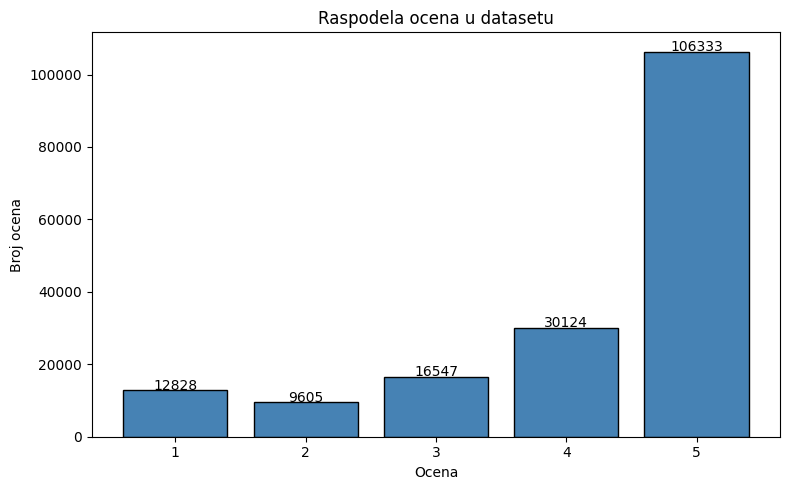


Raspodela ocena:
Score
1     12828
2      9605
3     16547
4     30124
5    106333
Name: count, dtype: int64


In [62]:
# Vizuelizacija raspodele ocena
plt.figure(figsize=(8, 5))

ocene_count = df["Score"].value_counts().sort_index()

plt.bar(ocene_count.index, ocene_count.values, color="steelblue", edgecolor="black")

plt.title("Raspodela ocena u datasetu")
plt.xlabel("Ocena")
plt.ylabel("Broj ocena")

for i, v in zip(ocene_count.index, ocene_count.values):
    plt.text(i, v + 100, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\nRaspodela ocena:")
print(ocene_count)

# Pravljenje matrice korisnik×proizvod

In [63]:
# matrica korisnik x proizvod
# redovi su korisnici, kolone su proizvodi, vrednosti su ocene
# gde korisnik nije ocenio proizvod, vrednost je 0

user_item_matrix = df.pivot_table(
    index="UserId",
    columns="ProductId",
    values="Score",
    fill_value=0
)

print("Oblik matrice (redovi x kolone):", user_item_matrix.shape)
print("\nPrvih 5 redova i 5 kolona matrice:")
print(user_item_matrix.iloc[:5, :5])

ukupno_celija = user_item_matrix.shape[0] * user_item_matrix.shape[1]
popunjeno_celija = (user_item_matrix != 0).sum().sum()
prazno_celija = 1 - (popunjeno_celija / ukupno_celija)
print("\nUkupno celija u matrici:", ukupno_celija)
print("Popunjeno celija:", popunjeno_celija)
print("Praznina matrice:", round(prazno_celija * 100, 2), "%")

Oblik matrice (redovi x kolone): (17666, 5012)

Prvih 5 redova i 5 kolona matrice:
ProductId       7310172001  7310172101  B00004CI84  B00004CXX9  B00004RAMY
UserId                                                                    
A1001WMV1CL0XH         0.0         0.0         0.0         0.0         0.0
A1004703RC79J9         0.0         0.0         0.0         0.0         0.0
A100IC7JRCQDUD         0.0         0.0         0.0         0.0         0.0
A100WO06OQR8BQ         0.0         0.0         0.0         0.0         0.0
A100ZQDV7L8PVV         0.0         0.0         0.0         0.0         0.0

Ukupno celija u matrici: 88541992
Popunjeno celija: 168277
Praznina matrice: 99.81 %


# Normalizacija podataka

In [64]:
# matrica u numpy niz
X = user_item_matrix.values.astype(np.float32)

# normalizacija ocena na opseg 0-1
# ocene su trenutno od 0 do 5
# delimo sa 5 da dobijemo opseg 0.0 do 1.0
X = X / 5.0

print("Oblik podataka:", X.shape)
print("Minimalna vrednost:", X.min())
print("Maksimalna vrednost:", X.max())
print("Tip podataka:", X.dtype)

Oblik podataka: (17666, 5012)
Minimalna vrednost: 0.0
Maksimalna vrednost: 1.0
Tip podataka: float32


# Podela na trening i test skup

In [65]:
# uzimamo prvih 5000 korisnika, da bi trening bio brzi
X = X[:5000]

# podela na trening i test skup
X_train, X_test = train_test_split(
    X,
    test_size=0.2,
    random_state=42
)

print("Trening skup:", X_train.shape)
print("Test skup:", X_test.shape)

Trening skup: (4000, 5012)
Test skup: (1000, 5012)


In [66]:
# proveravamo koliko ocena prosecno ima korisnik u nasem skupu
X_df = pd.DataFrame(X)
ocene_po_korisniku = (X_df != 0).sum(axis=1)

print("Prosecno ocena po korisniku:", round(ocene_po_korisniku.mean(), 2))
print("Minimum ocena:", ocene_po_korisniku.min())
print("Maximum ocena:", ocene_po_korisniku.max())

ukupno = X.shape[0] * X.shape[1]
popunjeno = (X != 0).sum()
praznina = 1 - (popunjeno / ukupno)
print("Praznina matrice:", round(praznina * 100, 2), "%")

Prosecno ocena po korisniku: 9.48
Minimum ocena: 2
Maximum ocena: 96
Praznina matrice: 99.81 %


#  Pravljenje DataLoadera i kreiranje batch-eva

In [67]:
# pretvaranje u PyTorch tenzore
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

# spajanje ulaza i očekivanog izlaza u parove
train_dataset = TensorDataset(X_train_tensor, X_train_tensor)
test_dataset = TensorDataset(X_test_tensor, X_test_tensor)

# pravljenje DataLoadera za batch trening
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print("Broj batch-eva u treningu:", len(train_loader))
print("Broj batch-eva u testu:", len(test_loader))

Broj batch-eva u treningu: 63
Broj batch-eva u testu: 16


# 3. Definisanje modela

In [68]:
class Autoencoder(nn.Module):
    def __init__(self, input_dim, latent_dim):
        super().__init__()

        # kompresovanje podataka
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
            nn.ReLU()
        )

        # rekonstrukcija podataka
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Funkcija greške

In [69]:
# MSELoss = Mean Squared Error
# meri koliko se rekonstruisane ocene razlikuju od originalnih
criterion = nn.MSELoss()

input_dim = X_train_tensor.shape[1]  # broj proizvoda
print("\nBroj proizvoda (ulaz/izlaz):", input_dim)


Broj proizvoda (ulaz/izlaz): 5012


# 4. Treniranje različitih modela autoenkodera

In [70]:
torch.manual_seed(42)

# Model 1 - Mali model sa latentnim prostorom 32
print("=== MODEL 1: latent=32, lr=0.001 ===")

model1 = Autoencoder(input_dim, latent_dim=32)
optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)

num_epochs = 50
patience = 10
best_loss1 = float('inf')
patience_counter = 0
train_losses1 = []
test_losses1 = []

for epoch in range(num_epochs):

    # --- TRENING ---
    model1.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:

        #predikcija
        output = model1(X_batch)

        # maska - uzimamo samo mesta gde postoji ocena (nije 0)
        # maska je True gde ima ocena, False gde nema
        mask = (X_batch != 0)

        # racunamo gresku samo na mestima gde ima ocena
        loss = criterion(output[mask], y_batch[mask])

        # brisanje starih gradijenata
        optimizer1.zero_grad()

        # backpropagation
        loss.backward()

        #azuriranje tezina
        optimizer1.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses1.append(avg_train_loss)


    # --- TESTIRANJE ---
    model1.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model1(X_batch)

            # ista maska i za testiranje
            mask = (X_batch != 0)
            loss = criterion(output[mask], y_batch[mask])
            epoch_test_loss += loss.item()
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses1.append(avg_test_loss)


    #ispis svake pete epohe
    if (epoch + 1) % 5 == 0:
        print(f"Epoha {epoch+1}/{num_epochs} | "
              f"Trening: {avg_train_loss:.4f} | "
              f"Test: {avg_test_loss:.4f}")


    # --- EARLY STOPPING ---
    if avg_test_loss < best_loss1:
        best_loss1 = avg_test_loss
        patience_counter = 0
        torch.save(model1.state_dict(), "model1.pth")
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping na epohi {epoch+1}")
        break

model1.load_state_dict(torch.load("model1.pth"))
print(f"\nNajbolja test greska: {best_loss1:.4f}")

=== MODEL 1: latent=32, lr=0.001 ===
Epoha 5/50 | Trening: 0.0218 | Test: 0.0442
Epoha 10/50 | Trening: 0.0118 | Test: 0.0394
Epoha 15/50 | Trening: 0.0090 | Test: 0.0402
Epoha 20/50 | Trening: 0.0076 | Test: 0.0394
Early stopping na epohi 21

Najbolja test greska: 0.0392


In [71]:
 # Model 2 - Srednji model sa latentnim prostorom 64 (nas trenutni)
print("=== MODEL 2: latent=64, lr=0.001 ===")

model2 = Autoencoder(input_dim, latent_dim=64)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)

best_loss2 = float('inf')
patience_counter = 0
train_losses2 = []
test_losses2 = []

for epoch in range(num_epochs):

    # --- TRENING ---
    model2.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:

        # predikcija
        output = model2(X_batch)

        # maska - uzimamo samo mesta gde postoji ocena (nije 0)
        # maska je True gde ima ocena, False gde nema
        mask = (X_batch != 0)

        # racunamo gresku samo na mestima gde ima ocena
        loss = criterion(output[mask], y_batch[mask])

        # brisanje starih gradijenata
        optimizer2.zero_grad()

        # backpropagation
        loss.backward()

        #azuriranje tezina
        optimizer2.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses2.append(avg_train_loss)


    # --- TESTIRANJE ---
    model2.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model2(X_batch)

            # ista maska i za testiranje
            mask = (X_batch != 0)
            loss = criterion(output[mask], y_batch[mask])
            epoch_test_loss += loss.item()
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses2.append(avg_test_loss)


    #ispis svake pete epohe
    if (epoch + 1) % 5 == 0:
        print(f"Epoha {epoch+1}/{num_epochs} | "
              f"Trening: {avg_train_loss:.4f} | "
              f"Test: {avg_test_loss:.4f}")


    # --- EARLY STOPPING ---
    if avg_test_loss < best_loss2:
        best_loss2 = avg_test_loss
        patience_counter = 0
        torch.save(model2.state_dict(), "model2.pth")
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping na epohi {epoch+1}")
        break

model2.load_state_dict(torch.load("model2.pth"))
print(f"\nNajbolja test greska: {best_loss2:.4f}")

=== MODEL 2: latent=64, lr=0.001 ===
Epoha 5/50 | Trening: 0.0231 | Test: 0.0421
Epoha 10/50 | Trening: 0.0121 | Test: 0.0387
Epoha 15/50 | Trening: 0.0091 | Test: 0.0385
Epoha 20/50 | Trening: 0.0074 | Test: 0.0395
Epoha 25/50 | Trening: 0.0067 | Test: 0.0401
Early stopping na epohi 25

Najbolja test greska: 0.0385


In [72]:
# Model 3 - Veci learning rate
print("=== MODEL 3: latent=64, lr=0.01 ===")

model3 = Autoencoder(input_dim, latent_dim=64)
optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.01)

best_loss3 = float('inf')
patience_counter = 0
train_losses3 = []
test_losses3 = []

for epoch in range(num_epochs):

    # --- TRENING ---
    model3.train()
    epoch_train_loss = 0.0
    for X_batch, y_batch in train_loader:

        # predikcija
        output = model3(X_batch)

         # maska - uzimamo samo mesta gde postoji ocena (nije 0)
        # maska je True gde ima ocena, False gde nema
        mask = (X_batch != 0)

        # racunamo gresku samo na mestima gde ima ocena
        loss = criterion(output[mask], y_batch[mask])

        # brisanje starih gradijenata
        optimizer3.zero_grad()

        # backpropagation
        loss.backward()

        #azuriranje tezina
        optimizer3.step()
        epoch_train_loss += loss.item()
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses3.append(avg_train_loss)


    # --- TESTIRANJE ---
    model3.eval()
    epoch_test_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            output = model3(X_batch)

            # ista maska i za testiranje
            mask = (X_batch != 0)
            loss = criterion(output[mask], y_batch[mask])
            epoch_test_loss += loss.item()
    avg_test_loss = epoch_test_loss / len(test_loader)
    test_losses3.append(avg_test_loss)

    #ispis svake pete epohe
    if (epoch + 1) % 5 == 0:
        print(f"Epoha {epoch+1}/{num_epochs} | "
              f"Trening: {avg_train_loss:.4f} | "
              f"Test: {avg_test_loss:.4f}")


    # --- EARLY STOPPING ---
    if avg_test_loss < best_loss3:
        best_loss3 = avg_test_loss
        patience_counter = 0
        torch.save(model3.state_dict(), "model3.pth")
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping na epohi {epoch+1}")
        break

model3.load_state_dict(torch.load("model3.pth"))
print(f"\nNajbolja test greska: {best_loss3:.4f}")

=== MODEL 3: latent=64, lr=0.01 ===
Epoha 5/50 | Trening: 0.0185 | Test: 0.0394
Epoha 10/50 | Trening: 0.0147 | Test: 0.0386
Epoha 15/50 | Trening: 0.0120 | Test: 0.0390
Epoha 20/50 | Trening: 0.0101 | Test: 0.0406
Epoha 25/50 | Trening: 0.0094 | Test: 0.0402
Early stopping na epohi 26

Najbolja test greska: 0.0383


# Poređenje i analiza rezultata

In [73]:
# Poredjenje svih modela
print("=== POREĐENJE MODELA ===\n")
print(f"{'Model':<30} {'Latent':>8} {'LR':>8} {'Test MSE':>10}")
print("-" * 60)
print(f"{'Mali model':<30} {'32':>8} {'0.001':>8} {best_loss1:>10.4f}")
print(f"{'Srednji model':<30} {'64':>8} {'0.001':>8} {best_loss2:>10.4f}")
print(f"{'Veci learning rate':<30} {'64':>8} {'0.01':>8} {best_loss3:>10.4f}")

# biramo najbolji model
losses = [best_loss1, best_loss2, best_loss3]
modeli = [model1, model2, model3]
nazivi = ["Mali model (latent=32)",
          "Srednji model (latent=64)",
          "Veci learning rate (lr=0.01)"]

najbolji_idx = np.argmin(losses)
finalni_model = modeli[najbolji_idx]

print(f"\nNajbolji model: {nazivi[najbolji_idx]}")
print(f"Test MSE: {losses[najbolji_idx]:.4f}")

=== POREĐENJE MODELA ===

Model                            Latent       LR   Test MSE
------------------------------------------------------------
Mali model                           32    0.001     0.0392
Srednji model                        64    0.001     0.0385
Veci learning rate                   64     0.01     0.0383

Najbolji model: Veci learning rate (lr=0.01)
Test MSE: 0.0383


# 5. Prikaz greške tokom treninga i testa najboljeg modela

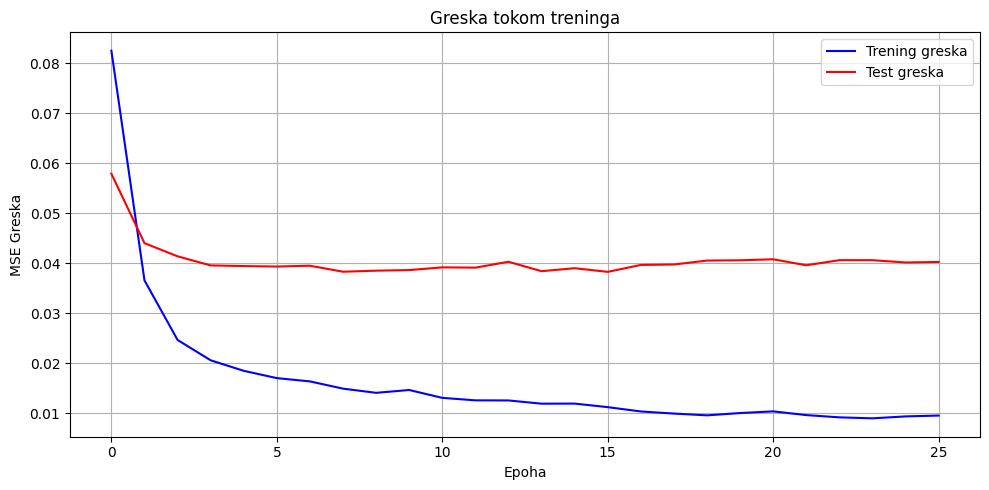

Pocetna trening greska: 0.0825
Krajnja trening greska: 0.0096
Pocetna test greska: 0.0579
Krajnja test greska: 0.0403
Najbolja test greska: 0.0383


In [74]:
# Crtanje grafa greske tokom treninga
# isto kao na vezbama - vizuelno pratimo kako greska pada

plt.figure(figsize=(10, 5))

plt.plot(train_losses3, label="Trening greska", color="blue")
plt.plot(test_losses3, label="Test greska", color="red")

plt.title("Greska tokom treninga")
plt.xlabel("Epoha")
plt.ylabel("MSE Greska")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("Pocetna trening greska:", round(train_losses3[0], 4))
print("Krajnja trening greska:", round(train_losses3[-1], 4))
print("Pocetna test greska:", round(test_losses3[0], 4))
print("Krajnja test greska:", round(test_losses3[-1], 4))
print("Najbolja test greska:", round(best_loss3, 4))

# 6. Evaluacija najboljeg modela

In [75]:
# racunamo MSE, RMSE i MAE

finalni_model.eval()
all_predictions = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = finalni_model(X_batch)

        # uzimamo samo mesta gde postoji ocena (maska)
        mask = (X_batch != 0)

        # cuvamo predikcije i tacne vrednosti
        all_predictions.append(output[mask].numpy())
        all_targets.append(y_batch[mask].numpy())

# spajamo sve batch-eve u jedan niz
all_predictions = np.concatenate(all_predictions)
all_targets = np.concatenate(all_targets)

# racunamo metrike na originalnoj skali (1-5)
# mnozimo sa 5 jer smo delili sa 5 tokom normalizacije
predictions_original = all_predictions * 5
targets_original = all_targets * 5

# MSE
mse = np.mean((predictions_original - targets_original) ** 2)

# RMSE
rmse = np.sqrt(mse)

# MAE
mae = np.mean(np.abs(predictions_original - targets_original))

print("=== EVALUACIJA MODELA ===")
print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
print(f"\nProsecna greska po oceni: {rmse:.2f} zvezda (na skali 1-5)")

=== EVALUACIJA MODELA ===
MSE:  0.9496
RMSE: 0.9744
MAE:  0.5820

Prosecna greska po oceni: 0.97 zvezda (na skali 1-5)


# 7. Prikaz ulaza i izlaza modela

In [76]:
# Prikaz ulaza i izlaza modela za jednog korisnika
# pokazujemo kako model rekonstruise ocene

finalni_model.eval()
with torch.no_grad():
    korisnik_ocene = torch.tensor(
        user_item_matrix.iloc[1].values / 5.0,
        dtype=torch.float32
    ).unsqueeze(0)

    rekonstrukcija = finalni_model(korisnik_ocene).squeeze(0).numpy()

# originalne ocene korisnika
originalne_ocene = user_item_matrix.iloc[1].values

# uzimamo samo ocenjene proizvode
ocenjeni = np.where(originalne_ocene != 0)[0]

print("=== ULAZ vs IZLAZ MODELA (Korisnik 1) ===")
print(f"\n{'Proizvod':<15} {'Ulaz':>18} {'Izlaz':>22}")
print("-" * 58)
for idx in ocenjeni:
    naziv = user_item_matrix.columns[idx]
    ulaz = originalne_ocene[idx]
    izlaz = rekonstrukcija[idx] * 5
    print(f"{naziv:<15} {ulaz:>18.1f} {izlaz:>22.2f}")

=== ULAZ vs IZLAZ MODELA (Korisnik 1) ===

Proizvod                      Ulaz                  Izlaz
----------------------------------------------------------
B001E50THY                     5.0                   4.86
B001OCKIP0                     4.0                   4.49
B002TMV34E                     3.0                   3.70
B003GTR8IO                     4.0                   3.61
B003XDH6M6                     4.0                   3.41
B004OV6X6Q                     2.0                   1.79
B0090X8IPM                     4.0                   3.62


# 8. Generisanje preporuka

In [77]:
def preporuci_proizvode(model, user_item_matrix, korisnik_idx, n_preporuka=5):

    model.eval()
    with torch.no_grad():
         # uzimamo ocene tog korisnika
        korisnik_ocene = torch.tensor(
            user_item_matrix.iloc[korisnik_idx].values / 5.0,
            dtype=torch.float32
        ).unsqueeze(0)
        # unsqueeze(0) dodaje dimenziju batch-a, pretvara [5012] u [1, 5012]
        # mreža očekuje [batch, proizvodi], a mi imamo samo [proizvodi]

        rekonstrukcija = model(korisnik_ocene)
        rekonstrukcija = rekonstrukcija.squeeze(0).numpy()
        # squeeze(0) uklanja dimenziju batch-a, pretvara [1, 5012] u [5012]

    # originalne ocene korisnika (nenormalizovane)
    originalne_ocene = user_item_matrix.iloc[korisnik_idx].values

    # proizvodi koje korisnik NIJE ocenio (True)
    neocenjeni = np.where(originalne_ocene == 0)[0]

    # od neocenjenih, uzimamo predvidjene ocene
    predvidjene_ocene = rekonstrukcija[neocenjeni]

    # sortiramo po predvidjenoj oceni (od najvece ka najmanjoj)
    top_indeksi = np.argsort(predvidjene_ocene)[::-1][:n_preporuka]
    top_proizvodi = neocenjeni[top_indeksi]

    # mnozimo sa 5 da dobijemo originalnu skalu
    top_ocene = predvidjene_ocene[top_indeksi] * 5
    nazivi_proizvoda = user_item_matrix.columns[top_proizvodi]

    # rezultat
    print(f"=== PREPORUKE ZA KORISNIKA {korisnik_idx} ===")
    print(f"\nProizvodi koje je korisnik VEC ocenio:")
    ocenjeni = np.where(originalne_ocene != 0)[0]
    for idx in ocenjeni[:5]:
        naziv = user_item_matrix.columns[idx]
        ocena = originalne_ocene[idx]
        print(f"  {naziv} -> ocena: {ocena:.1f}")

    print(f"\nTop {n_preporuka} preporuka:")
    for naziv, ocena in zip(nazivi_proizvoda, top_ocene):
        print(f"  {naziv} -> predvidjena ocena: {ocena:.2f}")

# preporuke za korisnika 0
preporuci_proizvode(finalni_model, user_item_matrix, korisnik_idx=0)
print()
# preporuke za korisnika 1
preporuci_proizvode(finalni_model, user_item_matrix, korisnik_idx=1)

=== PREPORUKE ZA KORISNIKA 0 ===

Proizvodi koje je korisnik VEC ocenio:
  B005DGI1IY -> ocena: 5.0
  B005DGI1PW -> ocena: 5.0
  B005DGI1VG -> ocena: 5.0
  B005DGI242 -> ocena: 5.0
  B005DGI2II -> ocena: 5.0

Top 5 preporuka:
  B000EVE3YE -> predvidjena ocena: 4.99
  B0030VJ70K -> predvidjena ocena: 4.99
  B0030VJ79Q -> predvidjena ocena: 4.99
  B005FKRTO0 -> predvidjena ocena: 4.99
  B0030VBPN2 -> predvidjena ocena: 4.99

=== PREPORUKE ZA KORISNIKA 1 ===

Proizvodi koje je korisnik VEC ocenio:
  B001E50THY -> ocena: 5.0
  B001OCKIP0 -> ocena: 4.0
  B002TMV34E -> ocena: 3.0
  B003GTR8IO -> ocena: 4.0
  B003XDH6M6 -> ocena: 4.0

Top 5 preporuka:
  B000EVE3YE -> predvidjena ocena: 4.95
  B001FA1KU8 -> predvidjena ocena: 4.92
  B0030VBPN2 -> predvidjena ocena: 4.92
  B0030VJ70K -> predvidjena ocena: 4.92
  B00474VPLI -> predvidjena ocena: 4.92


In [78]:
# trazimo korisnika koji ima niske i visoke ocene
for i in range(2, len(user_item_matrix)):
    ocene = user_item_matrix.iloc[i]
    nenulte = ocene[ocene != 0]
    if nenulte.min() <= 2 and nenulte.max() >= 4 and len(nenulte) >= 5:
        print(f"Nasao korisnika sa raznovrsnim ocenama: indeks {i}")
        preporuci_proizvode(finalni_model, user_item_matrix, korisnik_idx=i)
        break

Nasao korisnika sa raznovrsnim ocenama: indeks 3
=== PREPORUKE ZA KORISNIKA 3 ===

Proizvodi koje je korisnik VEC ocenio:
  B00004RBDU -> ocena: 1.0
  B0002XAFTG -> ocena: 1.0
  B000H7ELTW -> ocena: 5.0
  B000H7LVKY -> ocena: 5.0
  B000HDEHSQ -> ocena: 3.0

Top 5 preporuka:
  B000EVE3YE -> predvidjena ocena: 4.94
  B001FA1KU8 -> predvidjena ocena: 4.93
  B00474VPLI -> predvidjena ocena: 4.92
  B000V17MLS -> predvidjena ocena: 4.92
  B0030VJ70K -> predvidjena ocena: 4.91
